# SQL Query Classifier
This notebook trains a neural network to classify SQL queries as **slow** or **fast** based on structural features extracted from the query text.

The classifier is the first AI component of our live SQL monitor system. It runs before any API call is made, acting as a lightweight filter that decides whether a query is worth investigating further.

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cpu
CUDA available: False


## 2. Load the dataset
We load the CSV generated by our automated query runner. Each row is a SQL query with 8 extracted features and a label of either `slow` or `fast`.

In [4]:
df = pd.read_csv("../training_data.csv")

print(f"Total queries: {len(df)}")
print(f"Slow queries:  {(df['label'] == 'slow').sum()}")
print(f"Fast queries:  {(df['label'] == 'fast').sum()}")
print()
df.head()

Total queries: 463
Slow queries:  112
Fast queries:  351



,query_id,query_text,execution_time_ms,label,has_select_star,has_like_wildcard,join_count,has_subquery,has_group_by,has_order_by_no_limit,has_or,has_function_in_where
0,1,SELECT * FROM posts,30.89,fast,1,0,0,0,0,0,0,0
1,2,SELECT * FROM users,15.15,fast,1,0,0,0,0,0,0,0
2,3,SELECT * FROM votes,89.42,fast,1,0,0,0,0,0,0,0
3,4,SELECT * FROM posts ORDER BY score DESC,78.49,fast,1,0,0,0,0,1,0,0
4,5,SELECT * FROM users ORDER BY reputation DESC,82.94,fast,1,0,0,0,0,1,0,0


## 3. Visualize the dataset

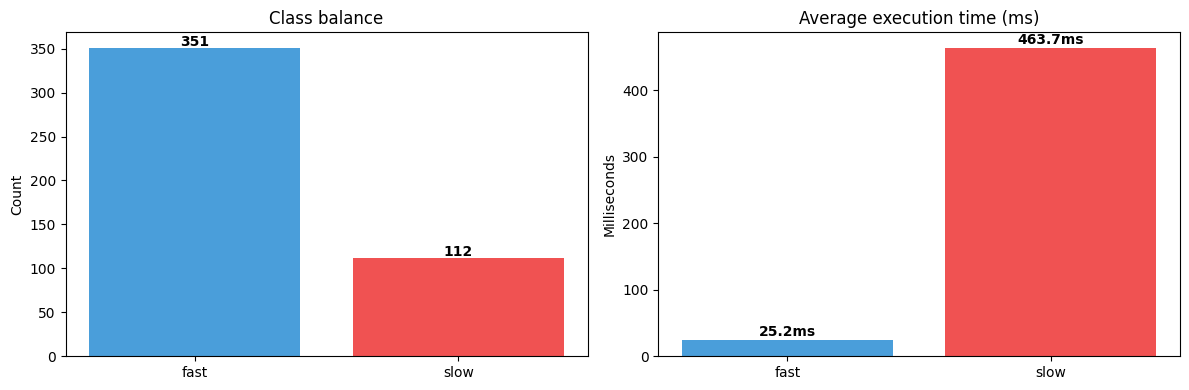

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# class balance
label_counts = df['label'].value_counts()
axes[0].bar(label_counts.index, label_counts.values, color=['#4a9eda', '#f05252'])
axes[0].set_title('Class balance')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# average execution time per label
avg_time = df.groupby('label')['execution_time_ms'].mean()
axes[1].bar(avg_time.index, avg_time.values, color=['#4a9eda', '#f05252'])
axes[1].set_title('Average execution time (ms)')
axes[1].set_ylabel('Milliseconds')
for i, v in enumerate(avg_time.values):
    axes[1].text(i, v + 5, f'{v:.1f}ms', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Feature analysis
We visualize how often each feature appears in slow vs fast queries. This helps us understand which features are most predictive.

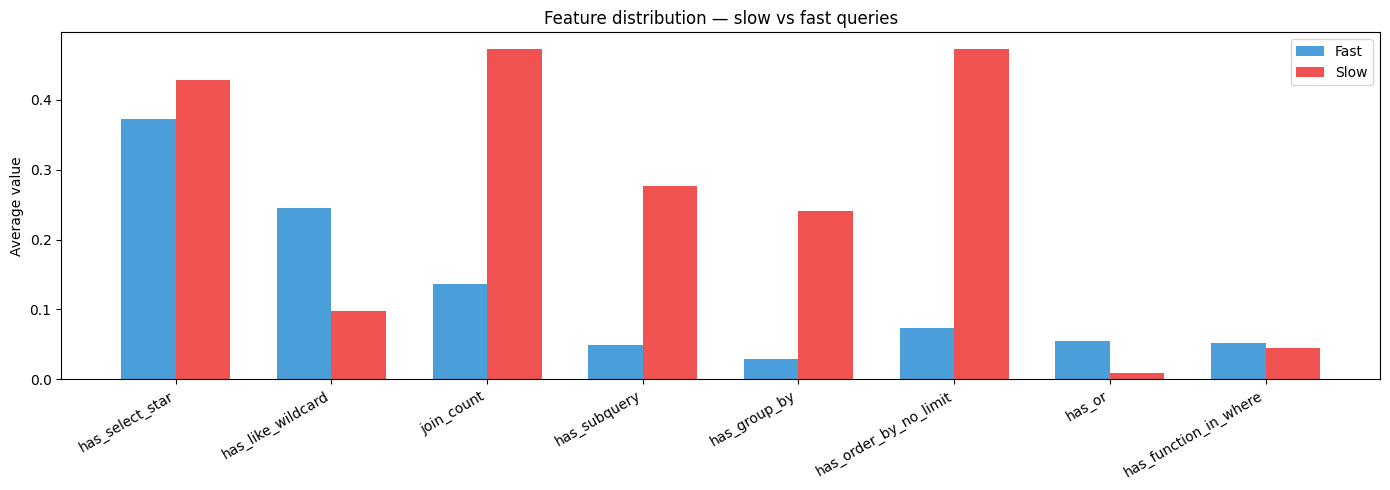

In [6]:
feature_cols = [
    "has_select_star",
    "has_like_wildcard",
    "join_count",
    "has_subquery",
    "has_group_by",
    "has_order_by_no_limit",
    "has_or",
    "has_function_in_where"
]

slow_df = df[df['label'] == 'slow']
fast_df = df[df['label'] == 'fast']

slow_means = slow_df[feature_cols].mean()
fast_means = fast_df[feature_cols].mean()

x = np.arange(len(feature_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, fast_means, width, label='Fast', color='#4a9eda')
ax.bar(x + width/2, slow_means, width, label='Slow', color='#f05252')
ax.set_xticks(x)
ax.set_xticklabels(feature_cols, rotation=30, ha='right')
ax.set_ylabel('Average value')
ax.set_title('Feature distribution — slow vs fast queries')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Prepare data for training
We split into train and test sets, then scale the features using StandardScaler so all values are on the same scale for the neural network.

In [7]:
X = df[feature_cols].values.astype(np.float32)
y = (df["label"] == "slow").astype(np.float32).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

Training samples: 370
Test samples:     93


## 6. Define the neural network
A simple 3-layer fully connected network with ReLU activations and dropout for regularization. The input is 8 features, the output is a single probability (slow or fast).

In [8]:
class QueryClassifier(nn.Module):
    def __init__(self):
        super(QueryClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(8, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

model = QueryClassifier()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

QueryClassifier(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Total parameters: 833


## 7. Train the model
We use Binary Cross Entropy loss with class weighting to handle the imbalanced dataset — slow queries are penalized more heavily when missed. The optimizer is Adam with a learning rate of 0.001.

In [9]:
slow_count = (y_train == 1).sum()
fast_count = (y_train == 0).sum()
pos_weight = torch.tensor([fast_count / slow_count], dtype=torch.float32)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 100
train_losses = []
test_accuracies = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    with torch.no_grad():
        preds = (model(X_test_t) > 0.5).float()
        acc = (preds == y_test_t).float().mean().item()
        test_accuracies.append(acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f} | Test Accuracy: {acc*100:.1f}%")

Epoch  10 | Loss: 0.9529 | Test Accuracy: 88.2%
Epoch  20 | Loss: 0.8708 | Test Accuracy: 89.2%
Epoch  30 | Loss: 0.8628 | Test Accuracy: 89.2%
Epoch  40 | Loss: 0.8653 | Test Accuracy: 89.2%
Epoch  50 | Loss: 0.8628 | Test Accuracy: 89.2%
Epoch  60 | Loss: 0.8617 | Test Accuracy: 89.2%
Epoch  70 | Loss: 0.8724 | Test Accuracy: 89.2%
Epoch  80 | Loss: 0.8619 | Test Accuracy: 89.2%
Epoch  90 | Loss: 0.8616 | Test Accuracy: 89.2%
Epoch 100 | Loss: 0.8604 | Test Accuracy: 89.2%


## 8. Training curves

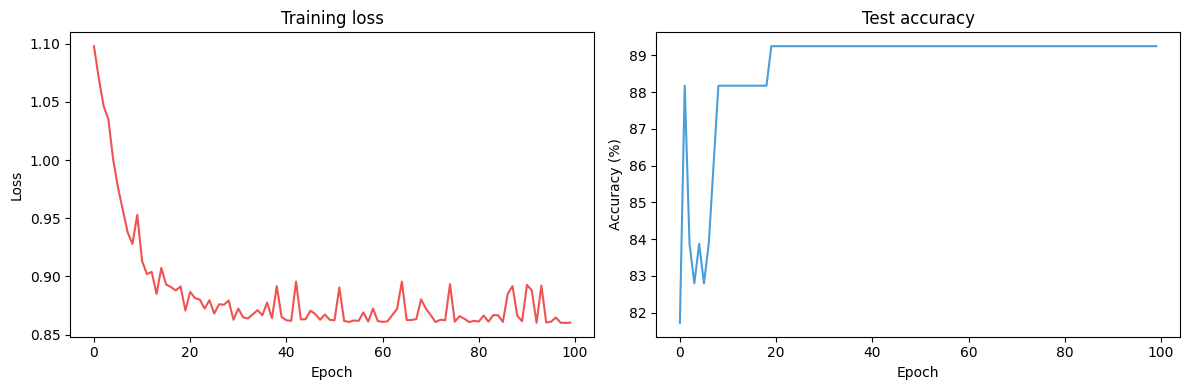

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, color='#f05252')
axes[0].set_title('Training loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot([a * 100 for a in test_accuracies], color='#4a9eda')
axes[1].set_title('Test accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()

## 9. Evaluate the model

              precision    recall  f1-score   support

        fast       0.93      0.93      0.93        71
        slow       0.77      0.77      0.77        22

    accuracy                           0.89        93
   macro avg       0.85      0.85      0.85        93
weighted avg       0.89      0.89      0.89        93



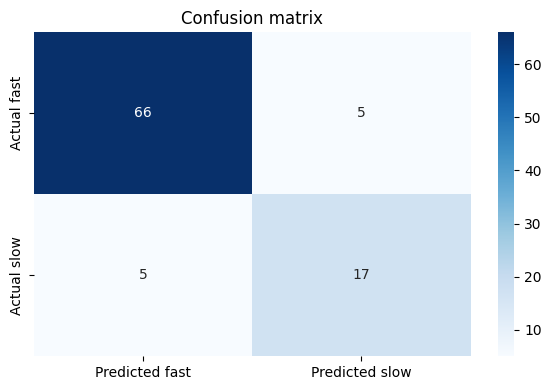

In [11]:
model.eval()
with torch.no_grad():
    preds = (model(X_test_t) > 0.5).float().numpy()
    y_true = y_test_t.numpy()

print(classification_report(y_true, preds, target_names=["fast", "slow"]))

cm = confusion_matrix(y_true, preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted fast', 'Predicted slow'],
            yticklabels=['Actual fast', 'Actual slow'])
plt.title('Confusion matrix')
plt.tight_layout()
plt.show()

## 10. Save the model
We save the trained model weights and the scaler so they can be loaded by the live monitor without retraining.

In [12]:
torch.save(model.state_dict(), "query_classifier.pth")
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model saved to query_classifier.pth")
print("Scaler saved to scaler.pkl")

Model saved to query_classifier.pth
Scaler saved to scaler.pkl
